In [21]:
import pandas as pd

# Път към файла (ако е в същата папка)
file_path = "customers-data.csv"

# Зареждане на CSV файла
df = pd.read_csv(file_path)

# Показване на редовете
df

# Информация за типовете данни
# print(df.info())

,customer_id,name,age,purchase_amount,product_category,purchase_date
0,1,Ivan Petrov,25.0,100.0,Electronics,2025-01-05
1,2,Maria Ivanova,30.0,200.0,Clothing,2025-01-06
2,2,Maria Ivanova,30.0,200.0,Clothing,2025-01-06
3,3,Georgi Georgiev,40.0,150.0,Books,2025-01-07
4,4,Anna Koleva,-5.0,50.0,Electronics,2025-01-08
5,5,NaN,28.0,NaN,Clothing,2025-01-09
6,6,Petar Dimitrov,35.0,300.0,Books,2025-01-10
7,7,Ivan Petrov,NaN,120.0,Electronics,2025-01-11
8,8,Maria Ivanova,32.0,250.0,Clothing,NaN
9,9,Georgi Georgiev,40.0,180.0,Electronics,2025-01-12


In [2]:
# Изчисляване на коефициента на Пирсън
correlation = df['age'].corr(df['purchase_amount'])
print("Коефициент на корелация на Пирсън между age и purchase_amount:", correlation)

Коефициент на корелация на Пирсън между age и purchase_amount: 0.6687699200118202


In [3]:
# Изчисляване на коефициента на Спирман
spearman_corr = df['age'].corr(df['purchase_amount'], method='spearman')
print("Коефициент на корелация на Спирман между age и purchase_amount:", spearman_corr)

Коефициент на корелация на Спирман между age и purchase_amount: 0.41212878113068263


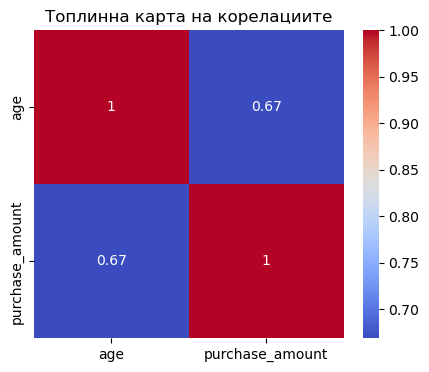

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Избираме само числовите колони
numeric_df = df[["age", "purchase_amount"]]

# Изчисляване на корелационна матрица (Pearson)
corr_matrix = numeric_df.corr(method="pearson")

# Визуализация чрез heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Топлинна карта на корелациите")
plt.show()

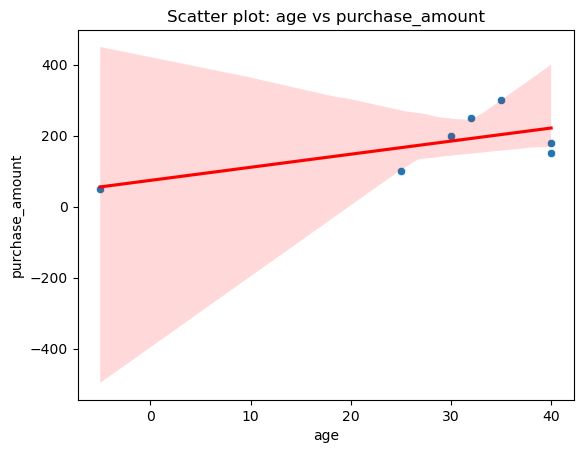

In [16]:
sns.scatterplot(data=df, x='age', y='purchase_amount')
sns.regplot(data=df, x='age', y='purchase_amount', scatter=False, color='red')
plt.title("Scatter plot: age vs purchase_amount")
plt.show()


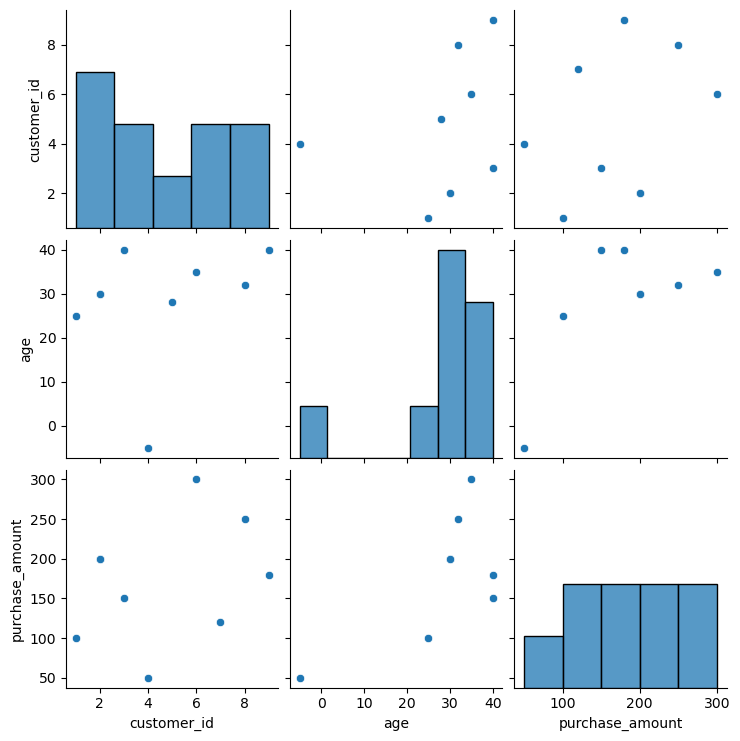

In [8]:
sns.pairplot(df)
plt.show()


In [2]:
import pandas as pd
import numpy as np

# Настройки
np.random.seed(42)
days = 30

# 1. Дневни продажби на онлайн магазин (с автокорелация)
sales_base = 50  # среден брой продажби
noise = np.random.normal(0, 5, size=days)  # малък шум
sales_online = np.zeros(days)
sales_online[0] = sales_base + noise[0]
sales_online[1] = sales_base + noise[1]
for i in range(2, days):
    sales_online[i] = 0.5*sales_online[i-1] + 0.3*sales_online[i-2] + noise[i]  # автокорелация

# 2. Продажби на кафе и десерти в кафетерия (положителна корелация)
coffee_sales = np.random.randint(20, 50, size=days)
dessert_sales = coffee_sales + np.random.randint(-5, 6, size=days)  # лек шум, но положителна зависимост

# Създаваме DataFrame
data = pd.DataFrame({
    "Day": pd.date_range(start="2026-01-01", periods=days, freq='D'),
    "Online_Sales": sales_online.astype(int),
    "Coffee_Sales": coffee_sales,
    "Dessert_Sales": dessert_sales
})

data.to_csv("sales_data.csv", index=False, encoding="utf-8")

data.head(10)


,Day,Online_Sales,Coffee_Sales,Dessert_Sales
0,2026-01-01,52,39,37
1,2026-01-02,49,47,49
2,2026-01-03,43,34,35
3,2026-01-04,44,47,50
4,2026-01-05,34,26,28
5,2026-01-06,29,31,30
6,2026-01-07,32,48,44
7,2026-01-08,28,27,26
8,2026-01-09,21,34,36
9,2026-01-10,22,22,26
